In [56]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, QuantileTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack, csr_matrix

from src.data_processing.data_loader import MovieLensDataLoader

In [57]:

loader = MovieLensDataLoader()
data_dict = loader.load_data()

print("Dobijamo metapodatke iz API...")

await loader.letterboxd_data_async(max_concurrent_requests=500)

print(f"\n[Easy] Dobijeno ovoliko filmova: {len(loader.movie_data)}")

if loader.movie_data:
    print("\nPrimer prvog filma:")
    import pprint
    pprint.pprint(loader.movie_data[0])
    
    df = pd.DataFrame(loader.movie_data)
    genre_features = loader.preprocess_movies()
    df = pd.concat([df, genre_features], axis=1)
    df = df.dropna().reset_index(drop=True)
    
    print("\nFinal dataframe shape:", df.shape)
    print("\nColumns:", list(df.columns))
    print("\nSample data:")
    print(df.head())
df.head(10)

INFO:src.data_processing.data_loader:Loading MovieLens dataset...
INFO:src.data_processing.data_loader:9742 films...


Dobijamo metapodatke iz API...


INFO:src.data_processing.data_loader:Successfully fetched from API: 5287 films.



[Easy] Dobijeno ovoliko filmova: 5287

Primer prvog filma:
{'cast': ['Steve Martin',
          'Diane Keaton',
          'Martin Short',
          'Kimberly Williams-Paisley',
          'George Newbern'],
 'director': 'Charles Shyer',
 'main_actor': 'Steve Martin',
 'rating': 6.3,
 'runtime': 106,
 'title': 'Father of the Bride Part II',
 'year': '1995'}

Final dataframe shape: (5265, 27)

Columns: ['title', 'year', 'cast', 'main_actor', 'director', 'rating', 'runtime', 'genre_(no genres listed)', 'genre_action', 'genre_adventure', 'genre_animation', 'genre_children', 'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_drama', 'genre_fantasy', 'genre_film-noir', 'genre_horror', 'genre_imax', 'genre_musical', 'genre_mystery', 'genre_romance', 'genre_sci-fi', 'genre_thriller', 'genre_war', 'genre_western']

Sample data:
                         title  year  \
0  Father of the Bride Part II  1995   
1                 Tom and Huck  1995   
2                        Balto  1995   
3 

,title,year,cast,main_actor,director,rating,runtime,genre_(no genres listed),genre_action,genre_adventure,...,genre_film-noir,genre_horror,genre_imax,genre_musical,genre_mystery,genre_romance,genre_sci-fi,genre_thriller,genre_war,genre_western
0,Father of the Bride Part II,1995,"[Steve Martin, Diane Keaton, Martin Short, Kim...",Steve Martin,Charles Shyer,6.300,106.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,Tom and Huck,1995,"[Jonathan Taylor Thomas, Brad Renfro, Eric Sch...",Jonathan Taylor Thomas,Peter Hewitt,5.300,97.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,Balto,1995,"[Kevin Bacon, Bob Hoskins, Bridget Fonda, Jim ...",Kevin Bacon,Simon Wells,7.321,78.0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,Nixon,1995,"[Anthony Hopkins, Joan Allen, Powers Boothe, E...",Anthony Hopkins,Oliver Stone,6.850,192.0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,Get Shorty,1995,"[John Travolta, Gene Hackman, Rene Russo, Dann...",John Travolta,Barry Sonnenfeld,6.504,105.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,Copycat,1995,"[Sigourney Weaver, Holly Hunter, Dermot Mulron...",Sigourney Weaver,Jon Amiel,6.476,124.0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
6,Assassins,1995,"[Sylvester Stallone, Antonio Banderas, Juliann...",Sylvester Stallone,Richard Donner,6.503,132.0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
7,Powder,1995,"[Mary Steenburgen, Sean Patrick Flanery, Lance...",Mary Steenburgen,Victor Salva,7.030,112.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
8,Leaving Las Vegas,1995,"[Nicolas Cage, Elisabeth Shue, Julian Sands, R...",Nicolas Cage,Mike Figgis,7.254,111.0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
9,Othello,1995,"[Laurence Fishburne, Irène Jacob, Kenneth Bran...",Laurence Fishburne,Oliver Parker,6.361,123.0,0,1,1,...,0,0,0,0,0,0,0,1,0,0


In [58]:
def cleaner(x):
    if isinstance(x, list):
        return [i.lower().replace(' ', '') for i in x]
    elif isinstance(x, str):
        return x.lower().replace(' ', '')
    return ""

In [59]:
df['title'] = df['title'].apply(cleaner)
df['main_actor'] = df['main_actor'].apply(cleaner)
df['director'] = df['director'].apply(cleaner)
df["cast"] = df["cast"].apply(cleaner).apply(lambda x: [i for i in x if i])
df.drop(columns=['rating'])

df.head(10)


,title,year,cast,main_actor,director,rating,runtime,genre_(no genres listed),genre_action,genre_adventure,...,genre_film-noir,genre_horror,genre_imax,genre_musical,genre_mystery,genre_romance,genre_sci-fi,genre_thriller,genre_war,genre_western
0,fatherofthebridepartii,1995,"[stevemartin, dianekeaton, martinshort, kimber...",stevemartin,charlesshyer,6.300,106.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,tomandhuck,1995,"[jonathantaylorthomas, bradrenfro, ericschweig...",jonathantaylorthomas,peterhewitt,5.300,97.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,balto,1995,"[kevinbacon, bobhoskins, bridgetfonda, jimcumm...",kevinbacon,simonwells,7.321,78.0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,nixon,1995,"[anthonyhopkins, joanallen, powersboothe, edha...",anthonyhopkins,oliverstone,6.850,192.0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,getshorty,1995,"[johntravolta, genehackman, renerusso, dannyde...",johntravolta,barrysonnenfeld,6.504,105.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,copycat,1995,"[sigourneyweaver, hollyhunter, dermotmulroney,...",sigourneyweaver,jonamiel,6.476,124.0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
6,assassins,1995,"[sylvesterstallone, antoniobanderas, juliannem...",sylvesterstallone,richarddonner,6.503,132.0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
7,powder,1995,"[marysteenburgen, seanpatrickflanery, lancehen...",marysteenburgen,victorsalva,7.030,112.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
8,leavinglasvegas,1995,"[nicolascage, elisabethshue, juliansands, rich...",nicolascage,mikefiggis,7.254,111.0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
9,othello,1995,"[laurencefishburne, irènejacob, kennethbranagh...",laurencefishburne,oliverparker,6.361,123.0,0,1,1,...,0,0,0,0,0,0,0,1,0,0


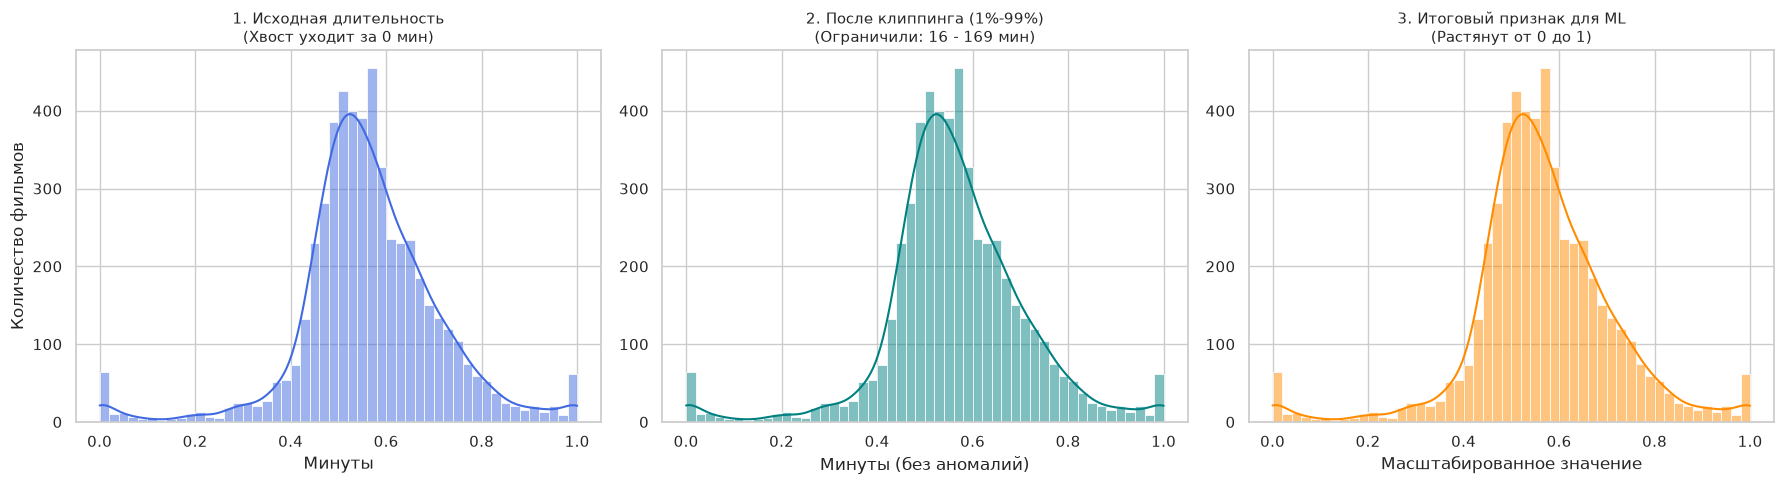

In [60]:
median_runtime = df["runtime"].replace(0, np.nan).median()
df["runtime"] = df["runtime"].replace(
    {0: median_runtime, np.nan: median_runtime}
)

lower_bound = df["runtime"].quantile(0.01)
upper_bound = df["runtime"].quantile(0.99)

df["runtime"] = df["runtime"].clip(lower_bound, upper_bound)

scaler = MinMaxScaler()
df["runtime"] = scaler.fit_transform(df[["runtime"]])

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(
    df["runtime"], bins=50, kde=True, ax=axes[0], color="royalblue"
)
axes[0].set_title(
    f"1. Исходная длительность\n(Хвост уходит за {int(df['runtime'].max())} мин)",
    fontsize=11,
)
axes[0].set_xlabel("Минуты")
axes[0].set_ylabel("Количество фильмов")

# График 2: Данные после клиппинга
sns.histplot(
    df["runtime"], bins=50, kde=True, ax=axes[1], color="teal"
)
axes[1].set_title(
    f"2. После клиппинга (1%-99%)\n(Ограничили: {int(lower_bound)} - {int(upper_bound)} мин)",
    fontsize=11,
)
axes[1].set_xlabel("Минуты (без аномалий)")
axes[1].set_ylabel("")

sns.histplot(
    df["runtime"], bins=50, kde=True, ax=axes[2], color="darkorange"
)
axes[2].set_title(
    "3. Итоговый признак для ML\n(Растянут от 0 до 1)", fontsize=11
)
axes[2].set_xlabel("Масштабированное значение")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

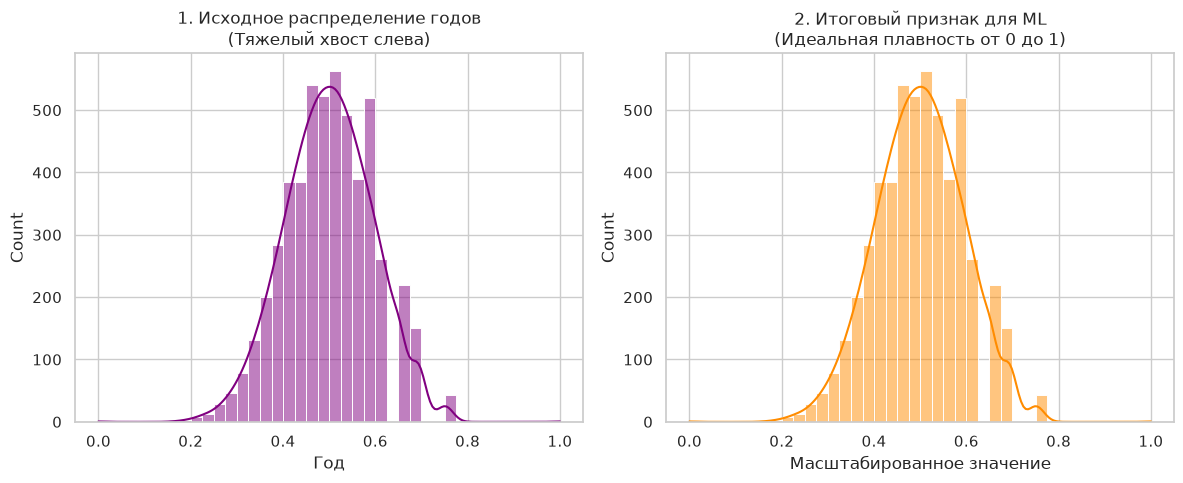

In [61]:
median_year = df["year"].astype(int).median()
df["year"] = df["year"].fillna(median_year)

qt_year = QuantileTransformer(
    output_distribution="normal", n_quantiles=1000, random_state=42
)
year_transformed = qt_year.fit_transform(df[["year"]])

scaler_year = MinMaxScaler()
df["year"] = scaler_year.fit_transform(year_transformed)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["year"], bins=40, kde=True, ax=axes[0], color="purple")
axes[0].set_title("1. Исходное распределение годов\n(Тяжелый хвост слева)")
axes[0].set_xlabel("Год")

sns.histplot(df["year"], bins=40, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("2. Итоговый признак для ML\n(Идеальная плавность от 0 до 1)")
axes[1].set_xlabel("Масштабированное значение")

plt.tight_layout()
plt.show()

In [62]:
df['main_actor_rating'] = df.groupby('main_actor')['rating'].transform('mean')
median_rating_actor = df["main_actor_rating"].replace(0, np.nan).median()
df["main_actor_rating"] = df["main_actor_rating"].replace({0: median_rating_actor, np.nan: median_rating_actor})

df["main_actor_rating"] = np.log1p(df["main_actor_rating"])

scaler = MinMaxScaler()
df["main_actor_rating"] = scaler.fit_transform(df[["main_actor_rating"]])

### ----------------------------------------------------------------------------------

df['director_rating'] = df.groupby('director')['rating'].transform('mean')
median_rating_director = df["director_rating"].replace(0, np.nan).median()
df["director_rating"] = df["director_rating"].replace({0: median_rating_director, np.nan: median_rating_director})

df["director_rating"] = np.log1p(df["director_rating"])

scaler = MinMaxScaler()
df["director_rating"] = scaler.fit_transform(df[["director_rating"]])

In [63]:
numerical_features = df[['runtime', 'year', 'main_actor_rating', 'director_rating']].values
numerical_matrix = csr_matrix(numerical_features)

In [64]:
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler

tfidf_main_actor = TfidfVectorizer()
main_actor_tfidf = tfidf_main_actor.fit_transform(df["main_actor"].fillna(""))

tfidf_director = TfidfVectorizer()
director_tfidf = tfidf_director.fit_transform(df["director"].fillna(""))

def weight_cast_members(cast_list):
    weighted_cast = []
    for i, actor in enumerate(cast_list):
        weight = max(1, 6 - i)
        weighted_cast.extend([actor] * weight)
    return ' '.join(weighted_cast)

df['cast'] = df['cast'].apply(
    lambda x: weight_cast_members(x) if isinstance(x, list) else str(x)
)

tfidf_cast = TfidfVectorizer(sublinear_tf=True)
cast_tfidf = tfidf_cast.fit_transform(df['cast'])

In [65]:
combined_features = hstack([
    main_actor_tfidf,
    director_tfidf,
    cast_tfidf,
    numerical_matrix
])

print(f"Combined features shape: {combined_features.shape}")
print(f"Non-zero elements: {combined_features.nnz}")

Combined features shape: (5265, 18567)
Non-zero elements: 58820


In [66]:
cosine_sim = cosine_similarity(combined_features)

print(f"Cosine similarity matrix shape: {cosine_sim.shape}")
print(f"Sample similarity (film 0 vs film 1): {cosine_sim[0, 1]}")

Cosine similarity matrix shape: (5265, 5265)
Sample similarity (film 0 vs film 1): 0.33702397631901215


In [ ]:
def get_similar_movies(movie_index, top_n=5):
    """Враћа топ-N најсличнијих филмова за дати филм"""
    sim_scores = list(enumerate(cosine_sim[movie_index]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Прескочи први (то је сам филм)
    similar_movies = sim_scores[1:top_n+1]
    
    results = []
    for idx, score in similar_movies:
        results.append({
            'index': idx,
            'title': df.iloc[idx]['title'],
            'similarity': score
        })
    
    return results

 # Пример употребе:
similar = get_similar_movies(9, top_n=5)
for movie in similar:
    print(f"{movie['title']}: {movie['similarity']:.4f}")

schooldaze: 0.6298
{'index': 1027, 'title': 'schooldaze', 'similarity': np.float64(0.6297561828864195)}
thetuskegeeairmen: 0.6193
{'index': 2340, 'title': 'thetuskegeeairmen', 'similarity': np.float64(0.6192631827461268)}
badcompany: 0.6166
{'index': 199, 'title': 'badcompany', 'similarity': np.float64(0.6166131170052332)}
doriangray: 0.5808
{'index': 3059, 'title': 'doriangray', 'similarity': np.float64(0.5808328443419093)}
johnnyenglishreborn: 0.5796
{'index': 3343, 'title': 'johnnyenglishreborn', 'similarity': np.float64(0.5795618200889987)}
